# ADMM for Sparse Recovery

Many inverse problems ask us to reconstruct a high-dimensional signal from far fewer measurements. Sparsity makes this possible: although the ambient vector has many coordinates, only a small number carry meaningful information. The central tension is that fitting the data and enforcing sparsity pull in different directions.

This notebook studies the LASSO estimator
$$
\min_{x\in\mathbb{R}^n}\; \frac12\lVert Ax-y\rVert_2^2+\lambda\lVert x\rVert_1,
$$
where $y=Ax_0$ is a set of linear measurements of a sparse target $x_0$. Rather than treating the solver as a black box, we split the two terms and follow the alternating direction method of multipliers (ADMM) step by step. The diagnostics make three distinct questions visible: does the constrained split become consistent, does the objective approach its dual bound, and does the estimate recover the sparse signal?


## Environment and numerical conventions

The experiment uses a normalized Gaussian sensing matrix $A\in\mathbb{R}^{m\times n}$ with $m<n$. All random quantities use a fixed generator, so the figures and convergence diagnostics are reproducible.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
from scipy.linalg import cho_factor, cho_solve

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'axes.spines.top': False, 'axes.spines.right': False})
rng = np.random.default_rng(0)

notebook_dir = Path('python/admm-first-principles')
snippet_path = notebook_dir / 'snippet.png' if notebook_dir.is_dir() else Path('snippet.png')


## A sparse measurement problem

We generate a vector $x_0$ with a small support $S=\{j:(x_0)_j\ne0\}$ and observe $y=Ax_0$. The reconstruction task is underdetermined because $m<n$, so least squares alone cannot identify a unique vector. The $\ell^1$ term is the convex mechanism that favors sparse explanations.


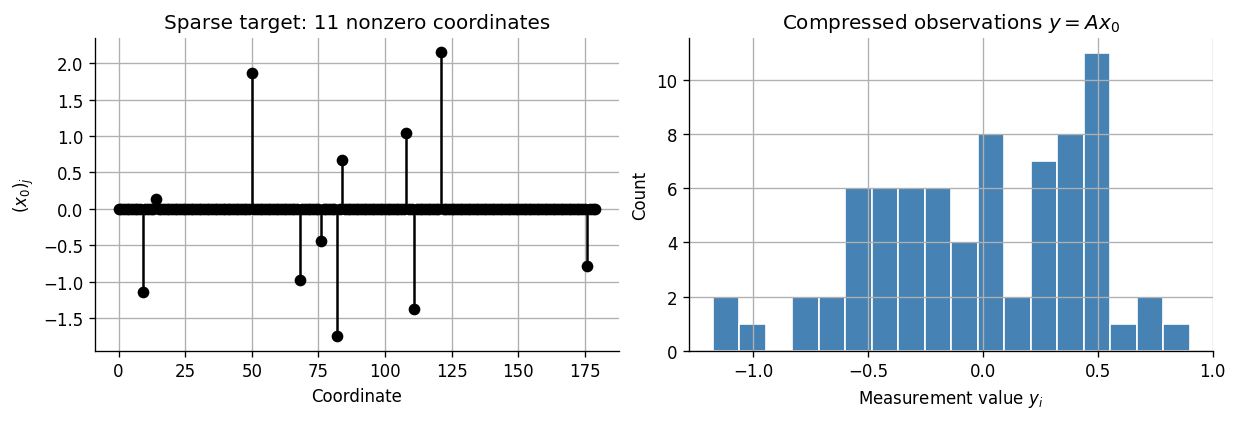

In [2]:
m, n = 75, 180
A = rng.normal(size=(m, n)) / np.sqrt(m)
x0 = np.zeros(n)
support = np.sort(rng.choice(n, size=11, replace=False))
x0[support] = rng.normal(0, 1.2, size=len(support))
y = A @ x0

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.4), constrained_layout=True)
axes[0].stem(np.arange(n), x0, linefmt='k-', markerfmt='ko', basefmt=' ')
axes[0].set(xlabel='Coordinate', ylabel=r'$(x_0)_j$', title=f'Sparse target: {len(support)} nonzero coordinates')
axes[1].hist(y, bins=18, color='steelblue', edgecolor='white')
axes[1].set(xlabel=r'Measurement value $y_i$', ylabel='Count', title=r'Compressed observations $y=Ax_0$')
plt.show()


## The critical regularization scale

The subgradient optimality condition at $x=0$ is
$$
0\in-A^\top y+\lambda\,\partial\lVert x\rVert_1\big|_{x=0}.
$$
Since $\partial\lVert x\rVert_1|_{x=0}=[-1,1]^n$, the zero vector is optimal exactly when
$$
\lambda\geq\lambda_{\max}:=\lVert A^\top y\rVert_\infty.
$$
We choose $\lambda=\lambda_{\max}/10$: it is small enough to permit a nonzero recovery, yet large enough to suppress many spurious coordinates.


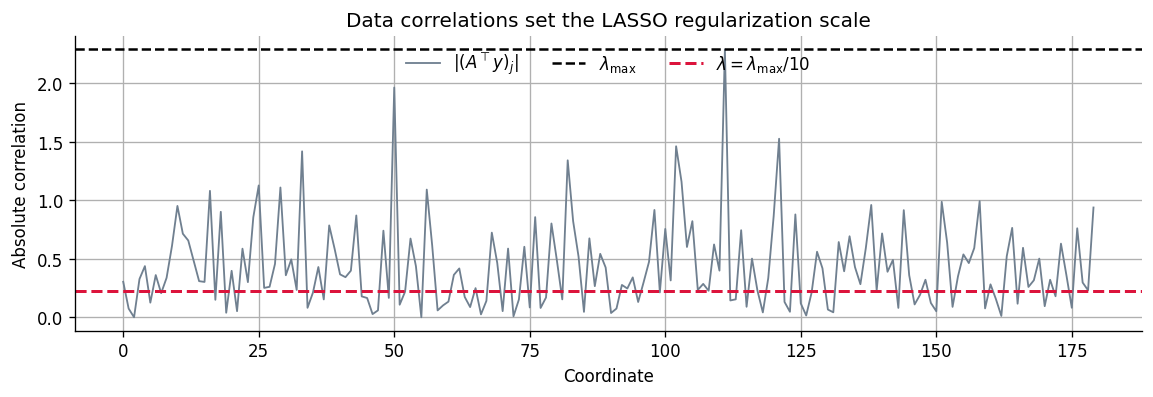

lambda_max = 2.291e+00; chosen lambda = 2.291e-01


In [3]:
correlations = np.abs(A.T @ y)
lam_max = correlations.max()
lam = lam_max / 10

fig, ax = plt.subplots(figsize=(9.5, 3.2), constrained_layout=True)
ax.plot(correlations, color='slategray', lw=1.1, label=r'$|(A^\top y)_j|$')
ax.axhline(lam_max, color='black', ls='--', lw=1.5, label=r'$\lambda_{\max}$')
ax.axhline(lam, color='crimson', ls='--', lw=1.8, label=r'$\lambda=\lambda_{\max}/10$')
ax.set(xlabel='Coordinate', ylabel='Absolute correlation', title='Data correlations set the LASSO regularization scale')
ax.legend(frameon=False, ncol=3, loc='upper center')
plt.show()

print(f'lambda_max = {lam_max:.3e}; chosen lambda = {lam:.3e}')


## ADMM splitting and proximal updates

Introduce a copy $z$ so that the smooth data term and the nonsmooth sparsity term are separated:
$$
\min_{x,z}\;\frac12\lVert Ax-y\rVert_2^2+\lambda\lVert z\rVert_1
\quad\text{subject to}\quad x-z=0.
$$
With scaled dual variable $u$ and penalty $\rho>0$, ADMM alternates
$$
\begin{aligned}
x^{k+1}&=(A^\top A+\rho I)^{-1}\big(A^\top y+\rho(z^k-u^k)\big),\\
z^{k+1}&=\operatorname{soft}_{\lambda/\rho}(x^{k+1}+u^k),\\
u^{k+1}&=u^k+x^{k+1}-z^{k+1},
\end{aligned}
$$
where $\operatorname{soft}_\tau(v)_j=\operatorname{sign}(v_j)\max(|v_j|-\tau,0)$ is coordinatewise soft thresholding.


In [4]:
rho = 1.0
n_iter = 180

def soft_threshold(values, threshold):
    return np.sign(values) * np.maximum(np.abs(values) - threshold, 0.0)

# The system matrix is fixed, so one Cholesky factorization serves all ADMM rounds.
system_factor = cho_factor(A.T @ A + rho * np.eye(n), lower=True, check_finite=False)


## Convergence quantities

The primal residual $r^k=x^k-z^k$ measures agreement of the two split variables, while the dual residual $s^k=\rho(z^k-z^{k-1})$ measures the change induced in the multiplier condition. To obtain an optimality certificate, we also compare the primal objective to a feasible LASSO dual value:
$$
D(\nu)=y^\top\nu-\frac12\lVert\nu\rVert_2^2,
\qquad \lVert A^\top\nu\rVert_\infty\leq\lambda.
$$
Scaling the measurement residual into this feasible dual ball gives a nonnegative primal-dual gap.


In [5]:
x = np.zeros(n)
z = np.zeros(n)
u = np.zeros(n)
x_hist = [x.copy()]
z_hist = [z.copy()]
primal_residual = []
dual_residual = []
primal_objective = []
dual_objective = []

for _ in range(n_iter):
    x = cho_solve(system_factor, A.T @ y + rho * (z - u), check_finite=False)
    z_previous = z
    z = soft_threshold(x + u, lam / rho)
    u = u + x - z

    residual = y - A @ z
    dual_scale = max(1.0, np.linalg.norm(A.T @ residual, ord=np.inf) / lam)
    nu = residual / dual_scale

    primal_objective.append(0.5 * np.dot(residual, residual) + lam * np.linalg.norm(z, ord=1))
    dual_objective.append(np.dot(y, nu) - 0.5 * np.dot(nu, nu))
    primal_residual.append(np.linalg.norm(x - z))
    dual_residual.append(rho * np.linalg.norm(z - z_previous))
    x_hist.append(x.copy())
    z_hist.append(z.copy())

x_hist = np.asarray(x_hist)
z_hist = np.asarray(z_hist)
relative_error = np.linalg.norm(z_hist - x0, axis=1) / np.linalg.norm(x0)
primal_objective = np.asarray(primal_objective)
dual_objective = np.asarray(dual_objective)
primal_dual_gap = np.maximum(primal_objective - dual_objective, 1e-16)


## Objective, residual, and recovery diagnostics

These three plots distinguish different notions of progress. The primal-dual gap checks optimization accuracy, the residuals check the ADMM consensus conditions, and the relative error compares the current sparse estimate to the known target. They need not decay at identical rates.


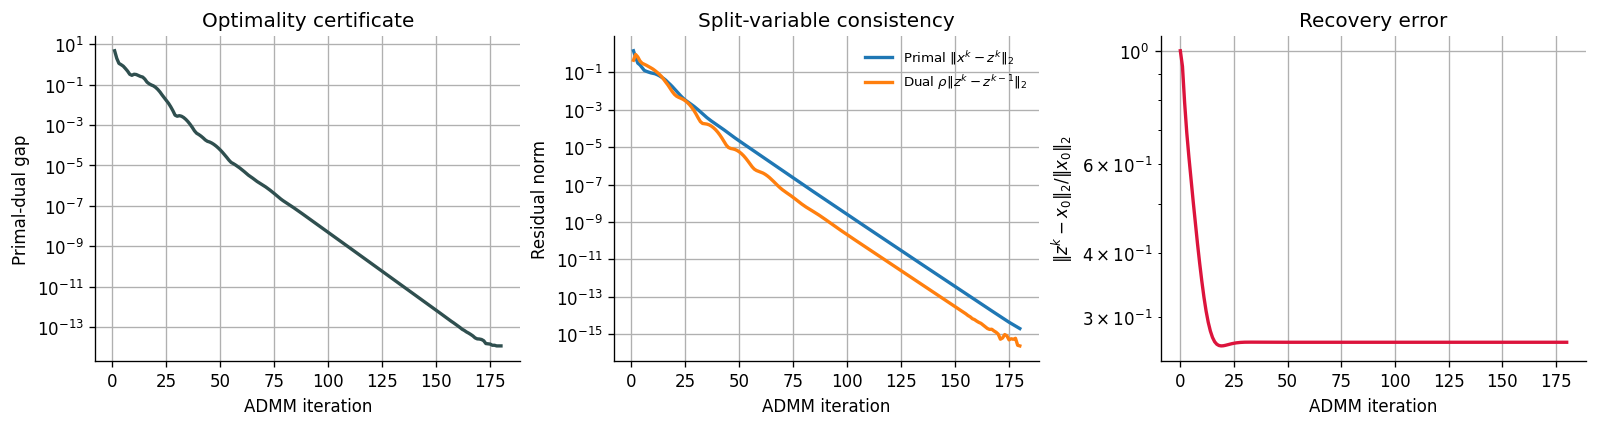

In [6]:
iterations = np.arange(1, n_iter + 1)
fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.45), constrained_layout=True)

axes[0].semilogy(iterations, primal_dual_gap, color='darkslategray', lw=2)
axes[0].set(xlabel='ADMM iteration', ylabel='Primal-dual gap', title='Optimality certificate')

axes[1].semilogy(iterations, primal_residual, lw=2, label=r'Primal $\|x^k-z^k\|_2$')
axes[1].semilogy(iterations, dual_residual, lw=2, label=r'Dual $\rho\|z^k-z^{k-1}\|_2$')
axes[1].set(xlabel='ADMM iteration', ylabel='Residual norm', title='Split-variable consistency')
axes[1].legend(frameon=False, fontsize=8)

axes[2].semilogy(np.arange(n_iter + 1), relative_error, color='crimson', lw=2)
axes[2].set(xlabel='ADMM iteration', ylabel=r'$\|z^k-x_0\|_2/\|x_0\|_2$', title='Recovery error')
plt.show()


## The sparse estimate emerges over time

Soft thresholding quickly suppresses many coordinates, while repeated $x$-updates refine the amplitude of the surviving ones. The snapshots show $z^k$, the sparse variable directly penalized by the $\ell^1$ term, overlaid on the target support.


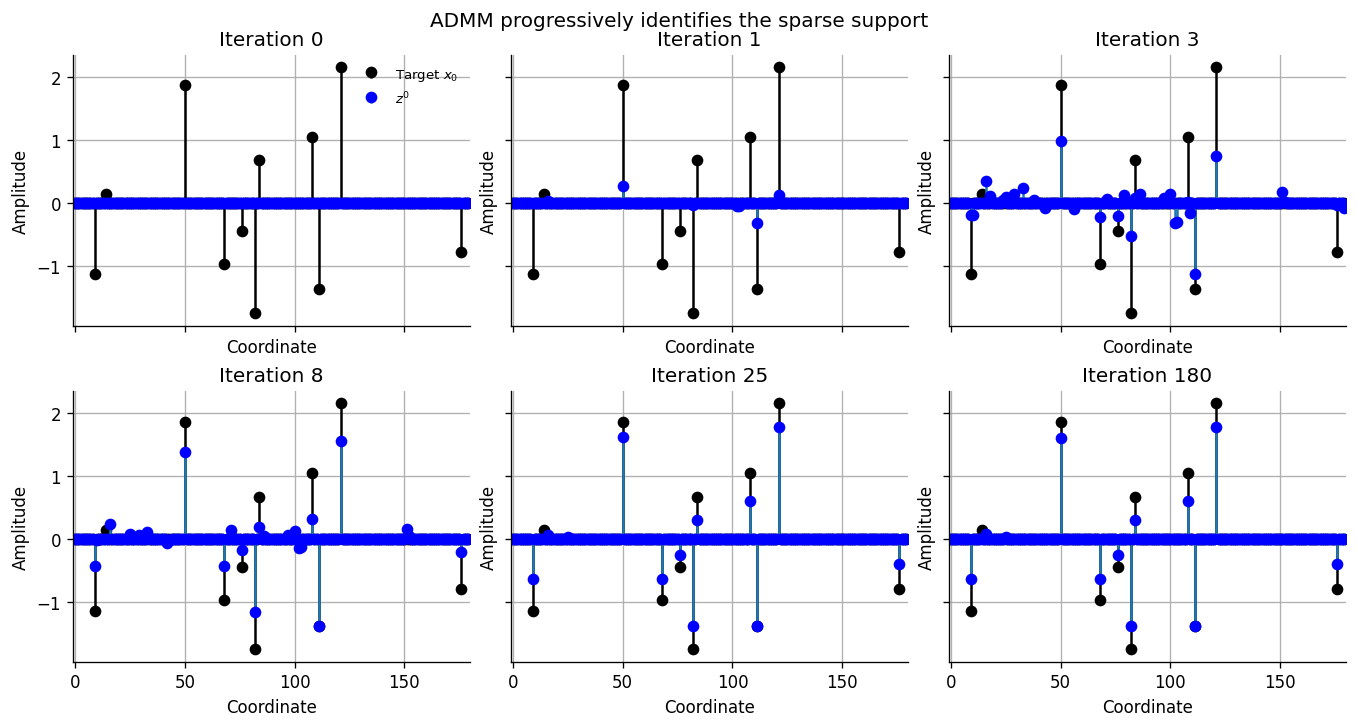

In [7]:
snapshot_iterations = [0, 1, 3, 8, 25, n_iter]
fig, axes = plt.subplots(2, 3, figsize=(11.2, 5.8), sharex=True, sharey=True, constrained_layout=True)
for ax, iteration in zip(axes.flat, snapshot_iterations):
    ax.stem(np.arange(n), x0, linefmt='k-', markerfmt='ko', basefmt=' ', label=r'Target $x_0$')
    ax.stem(np.arange(n), z_hist[iteration], linefmt='tab:blue', markerfmt='bo', basefmt=' ', label=rf'$z^{{{iteration}}}$')
    ax.set_title(f'Iteration {iteration}')
    ax.set(xlim=(-1, n), xlabel='Coordinate', ylabel='Amplitude')
axes[0, 0].legend(loc='upper right', frameon=False, fontsize=8)
fig.suptitle('ADMM progressively identifies the sparse support', y=1.02)
plt.show()


## Final reconstruction

The final estimate should be sparse, data-consistent, and close to the target. The left panel compares the recovered coefficients directly; the right panel identifies support decisions. A true positive is a coordinate retained by both $x_0$ and the estimate, while a false positive is a nonzero coefficient introduced outside the target support.


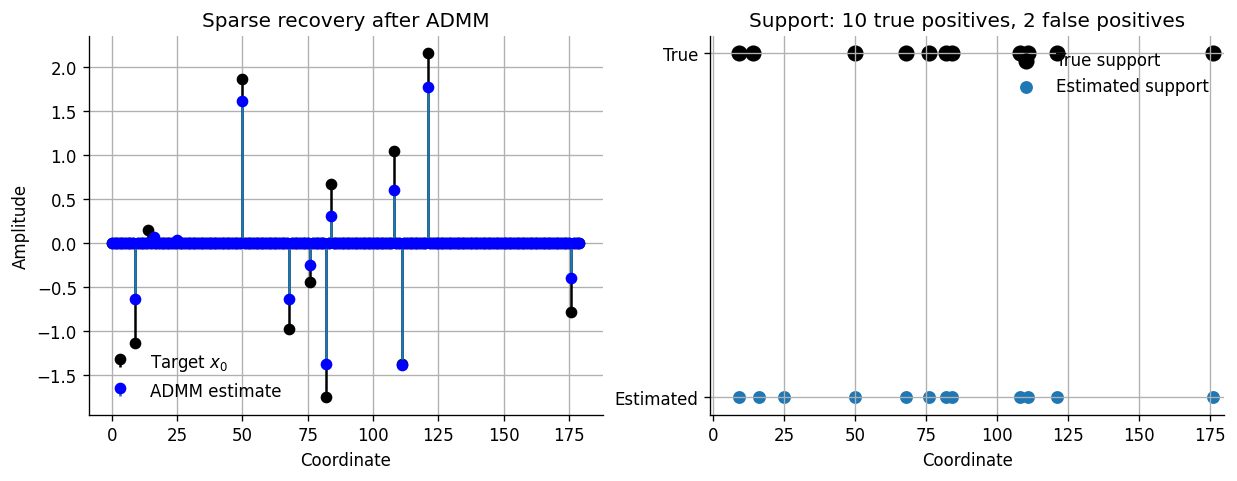

In [8]:
estimate = z_hist[-1]
support_tolerance = 1e-3
estimated_support = np.abs(estimate) > support_tolerance
true_support = np.abs(x0) > 0
true_positive = np.sum(estimated_support & true_support)
false_positive = np.sum(estimated_support & ~true_support)

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.9), constrained_layout=True)
axes[0].stem(np.arange(n), x0, linefmt='k-', markerfmt='ko', basefmt=' ', label=r'Target $x_0$')
axes[0].stem(np.arange(n), estimate, linefmt='tab:blue', markerfmt='bo', basefmt=' ', label='ADMM estimate')
axes[0].set(xlabel='Coordinate', ylabel='Amplitude', title='Sparse recovery after ADMM')
axes[0].legend(frameon=False)

axes[1].scatter(np.flatnonzero(true_support), np.ones(true_support.sum()), s=75, color='black', label='True support')
axes[1].scatter(np.flatnonzero(estimated_support), np.zeros(estimated_support.sum()), s=45, color='tab:blue', label='Estimated support')
axes[1].set(yticks=[0, 1], yticklabels=['Estimated', 'True'], xlim=(-1, n), xlabel='Coordinate', title=f'Support: {true_positive} true positives, {false_positive} false positives')
axes[1].legend(frameon=False, loc='upper right')

snippet_fig, snippet_ax = plt.subplots(figsize=(5.0, 5.0), constrained_layout=True)
snippet_ax.stem(np.arange(n), x0, linefmt='k-', markerfmt='ko', basefmt=' ', label=r'Target $x_0$')
snippet_ax.stem(np.arange(n), estimate, linefmt='tab:blue', markerfmt='bo', basefmt=' ', label='ADMM estimate')
snippet_ax.set(xlim=(-1, n), xlabel='Coordinate', ylabel='Amplitude', title='Sparse recovery with ADMM')
snippet_ax.legend(frameon=False, loc='upper right')
snippet_fig.savefig(snippet_path, bbox_inches='tight', facecolor='white')
plt.close(snippet_fig)
plt.show()


## Interactive iterate explorer

The slider exposes the same sparse iterate sequence at arbitrary rounds. This exploration is supplementary: the static snapshots and diagnostics above contain the complete numerical story and remain available when the notebook is executed non-interactively.


In [9]:
@interact(iteration=IntSlider(value=25, min=0, max=n_iter, step=1, description='Iteration', continuous_update=False))
def inspect_iterate(iteration):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
    axes[0].stem(np.arange(n), x0, linefmt='k-', markerfmt='ko', basefmt=' ', label=r'Target $x_0$')
    axes[0].stem(np.arange(n), z_hist[iteration], linefmt='tab:blue', markerfmt='bo', basefmt=' ', label=rf'$z^{{{iteration}}}$')
    axes[0].set(xlim=(-1, n), xlabel='Coordinate', ylabel='Amplitude', title=f'Sparse estimate at iteration {iteration}')
    axes[0].legend(frameon=False)

    ax = axes[1]
    ax.semilogy(iterations, primal_dual_gap, color='darkslategray', lw=2, label='Primal-dual gap')
    if iteration > 0:
        ax.axvline(iteration, color='crimson', ls='--', label=f'Iteration {iteration}')
    ax.set(xlabel='ADMM iteration', ylabel='Gap', title='Optimization progress')
    ax.legend(frameon=False)
    plt.show()


interactive(children=(IntSlider(value=25, continuous_update=False, description='Iteration', max=180), Output()…

## Takeaways

ADMM makes the LASSO structure explicit: a quadratic solve enforces measurement fidelity, soft thresholding promotes sparsity, and a dual correction keeps the two copies consistent. The residuals and primal-dual gap provide solver-level evidence, while the iterate snapshots reveal the mechanism by which sparse support is identified.


## Bibliographical resources

- Stephen Boyd, Neal Parikh, Eric Chu, Borja Peleato, and Jonathan Eckstein, *Distributed Optimization and Statistical Learning via the Alternating Direction Method of Multipliers*, 2011.
- Ryan Tibshirani, *Regression Shrinkage and Selection via the Lasso*, 1996.
- Stephen Boyd and Lieven Vandenberghe, *Convex Optimization*, 2004, Chapters 5 and 6.
- Neal Parikh and Stephen Boyd, *Proximal Algorithms*, 2014.
